# 04 - Topic Analysis

Post-processes raw BERTopic output and produces topic-level visualisations.

In [ ]:
import sys
sys.path.append("../functions")

import ast
import math
from collections import defaultdict, Counter
from itertools import combinations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import (
    DATA_DIR, FIGURES_DIR,
    TOPIC_COLOURS, HOUSING_ORDER, HOUSING_TYPE_COLOURS, INNER_LONDON_BOROUGHS,
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Load and process topics

In [ ]:
topic_names = pd.read_csv(DATA_DIR / "topic_names.csv")
topic_name_lookup = topic_names.set_index("Topic")["topic_group"].to_dict()
topic_names.head()

## Merge comments with topics and planning data

In [ ]:
df = pd.read_csv(DATA_DIR / "comments_with_topics.csv")
df["topic_number"] = df["topic_number"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
print(f"{len(df):,} comments loaded")
df.head()

## Topic frequency (all London)

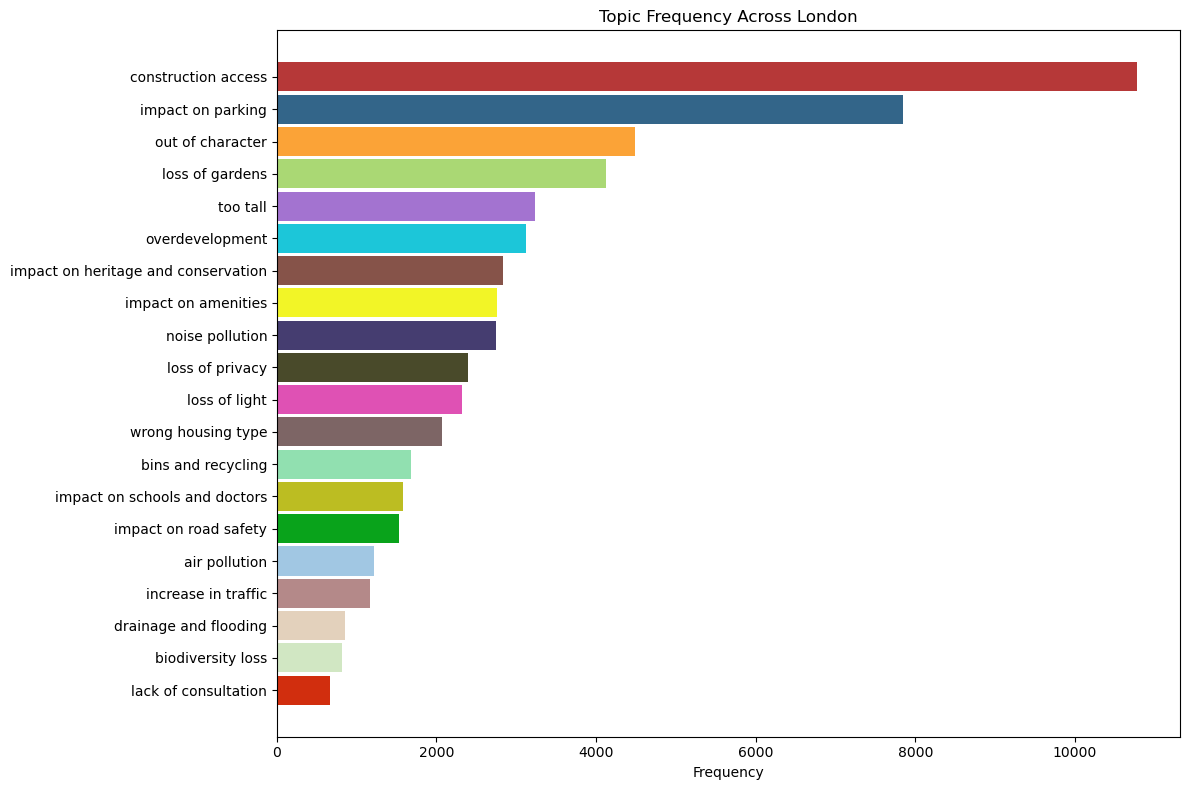

In [ ]:
all_topics  = df["topic_number"].explode()
topic_counts = all_topics.value_counts().rename("count")

# sort by frequency
ordered_topics = topic_names[["Topic", "topic_group", "color"]].merge(topic_counts, left_on="Topic", right_index=True, how="left").fillna({"count": 0})
ordered_topics = ordered_topics.sort_values("count", ascending=False).reset_index(drop=True)

plot_df = (
    ordered_topics
)
plot_df["Percentage"] = (plot_df["count"] / plot_df["count"].sum() * 100).round(2)

n_vals = 20
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(plot_df["topic_group"].iloc[:n_vals],
        plot_df["count"].iloc[:n_vals],
        color=plot_df["color"].iloc[:n_vals], height=0.9)
ax.invert_yaxis()
ax.set_xlabel("Frequency")
ax.set_title("Topic Frequency Across London")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "topic_frequency.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:

# Load topic names and counts directly from local model output (no DB needed)
_all = topic_names

_top = _all.head(20).copy()
_other_count = _all.iloc[20:]["Count"].sum()
_other = pd.DataFrame([{"topic_group": "other", "Count": _other_count, "color": "#888888"}])
_pie_df = pd.concat([_top, _other], ignore_index=True)

fig, ax = plt.subplots(figsize=(16, 16), facecolor="black")
ax.set_facecolor("black")

wedges, texts, autotexts = ax.pie(
    _pie_df["Count"],
    labels=_pie_df["topic_group"],
    colors=_pie_df["color"],
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.80,
    labeldistance=1.12,
    wedgeprops={"linewidth": 0.8, "edgecolor": "black"},
)

# Rotate each label radially so it fans out from the pie centre
for text, wedge in zip(texts, wedges):
    mid_angle = (wedge.theta1 + wedge.theta2) / 2
    x, _ = text.get_position()
    if x >= 0:                                               # right-hand side
        text.set_rotation(mid_angle)
        text.set_ha("left")
    else:                                                    # left-hand side — flip so text reads outward
        text.set_rotation(mid_angle + 180)
        text.set_ha("right")
    text.set_rotation_mode("anchor")
    text.set_color("white")
    text.set_fontsize(14)
    text.set_fontweight("bold")

for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(12)

# ax.set_title("Topic Frequency Across London", color="white", fontsize=20, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "topic_frequency_pie.png", dpi=150, bbox_inches="tight", facecolor="black")
plt.show()


In [ ]:

# Topics considered 'NIMBY' — adjust this set as needed
NIMBY_TOPIC_IDS = {
    1,   # impact on parking
    2,   # loss of gardens
    3,   # out of character
    5,   # too tall
    8,   # loss of privacy
    9,   # loss of light
    11,  # overdevelopment
    12,  # noise pollution
    17,  # bins and recycling
    28,  # loss of view
    33,  # impact on property value
    55,  # light pollution
    58,  # eyesore
}

_all = topic_names

_top = _all.head(20).copy()
_other_count = _all.iloc[20:]["Count"].sum()
_other = pd.DataFrame([{"Topic": -999, "topic_group": "other", "Count": _other_count, "color": "#888888"}])
_pie_df = pd.concat([_top, _other], ignore_index=True)

# Non-NIMBY wedges go black so they vanish against the background
_colors = [
    row["color"] if row["Topic"] in NIMBY_TOPIC_IDS else "#000000"
    for _, row in _pie_df.iterrows()
]

fig, ax = plt.subplots(figsize=(16, 16), facecolor="black")
ax.set_facecolor("black")

wedges, texts, autotexts = ax.pie(
    _pie_df["Count"],
    labels=_pie_df["topic_group"],
    colors=_colors,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.80,
    labeldistance=1.12,
    wedgeprops={"linewidth": 0.8, "edgecolor": "black"},
)

for text, wedge, (_, row) in zip(texts, wedges, _pie_df.iterrows()):
    mid_angle = (wedge.theta1 + wedge.theta2) / 2
    x, _ = text.get_position()
    is_nimby = row["Topic"] in NIMBY_TOPIC_IDS
    if x >= 0:
        text.set_rotation(mid_angle)
        text.set_ha("left")
    else:
        text.set_rotation(mid_angle + 180)
        text.set_ha("right")
    text.set_rotation_mode("anchor")
    text.set_color("white" if is_nimby else "black")
    text.set_fontsize(14)
    text.set_fontweight("bold")

for autotext, (_, row) in zip(autotexts, _pie_df.iterrows()):
    autotext.set_color("white" if row["Topic"] in NIMBY_TOPIC_IDS else "black")
    autotext.set_fontsize(12)

# ax.set_title("NIMBY Topics — Frequency Across London", color="white", fontsize=20, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "topic_frequency_pie_nimby.png", dpi=150, bbox_inches="tight", facecolor="black")
plt.show()


## Inner vs outer London split

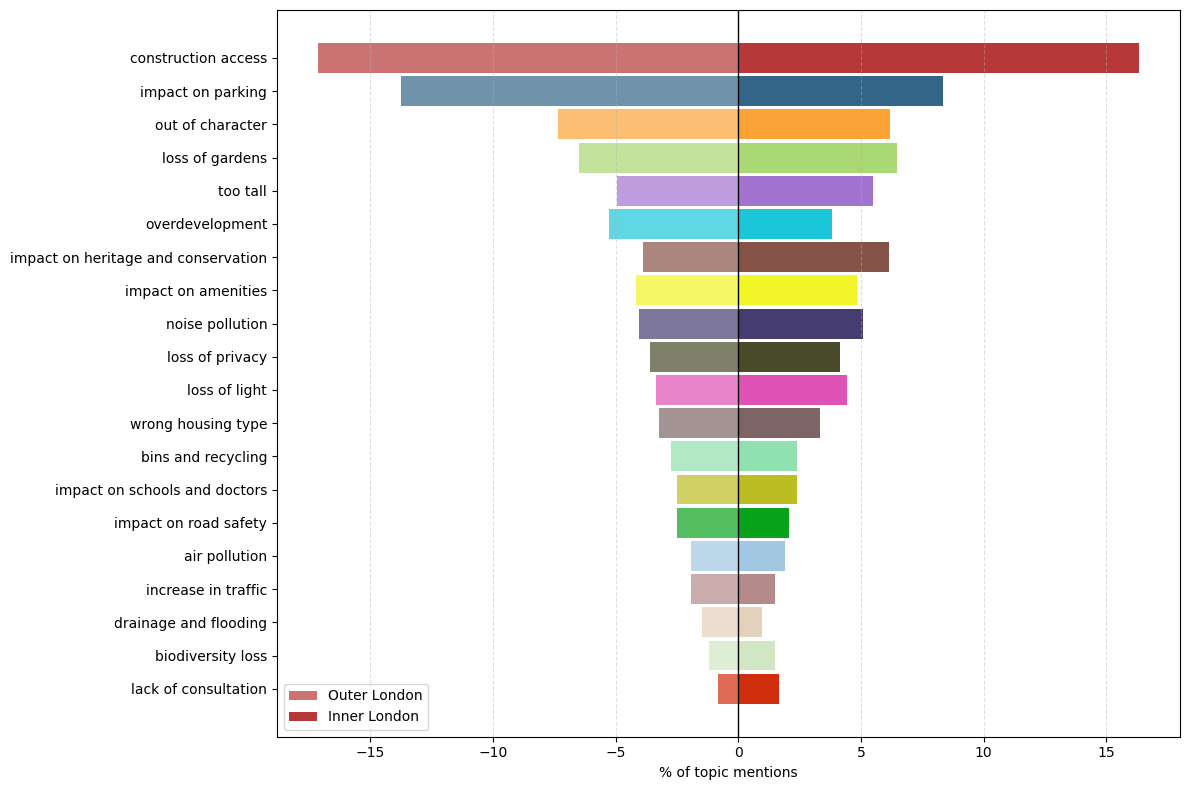

In [ ]:
outer_boroughs = [c for c in df["council"].unique() if c not in INNER_LONDON_BOROUGHS]

inner_counts = (df[df["council"].isin(INNER_LONDON_BOROUGHS)]["topic_number"]
                .explode().value_counts().rename("inner"))
outer_counts = (df[df["council"].isin(outer_boroughs)]["topic_number"]
                .explode().value_counts().rename("outer"))

plot_df = plot_df.merge(inner_counts, left_on="Topic", right_index=True, how="left")
plot_df = plot_df.merge(outer_counts, left_on="Topic", right_index=True, how="left")
plot_df[["inner", "outer"]] = plot_df[["inner", "outer"]].fillna(0)

# total = plot_df["inner"] + plot_df["outer"]
plot_df["inner_pct"] = (plot_df["inner"] / plot_df["inner"].sum() * 100).round(2)
plot_df["outer_pct"] = (plot_df["outer"] / plot_df["outer"].sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(plot_df["topic_group"].iloc[:n_vals],
        -plot_df["outer_pct"].iloc[:n_vals],
        color=plot_df["color"].iloc[:n_vals], height=0.9, alpha=0.7, label="Outer London")
ax.barh(plot_df["topic_group"].iloc[:n_vals],
        plot_df["inner_pct"].iloc[:n_vals],
        color=plot_df["color"].iloc[:n_vals], height=0.9, label="Inner London")
ax.axvline(0, color="black", linewidth=1)
ax.invert_yaxis()
ax.set_xlabel("% of topic mentions")
ax.grid(axis='x', linestyle='--', linewidth=0.8, alpha=0.4)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "topic_inner_outer_london.png", dpi=150, bbox_inches="tight")
plt.show()

## Topics by housing type

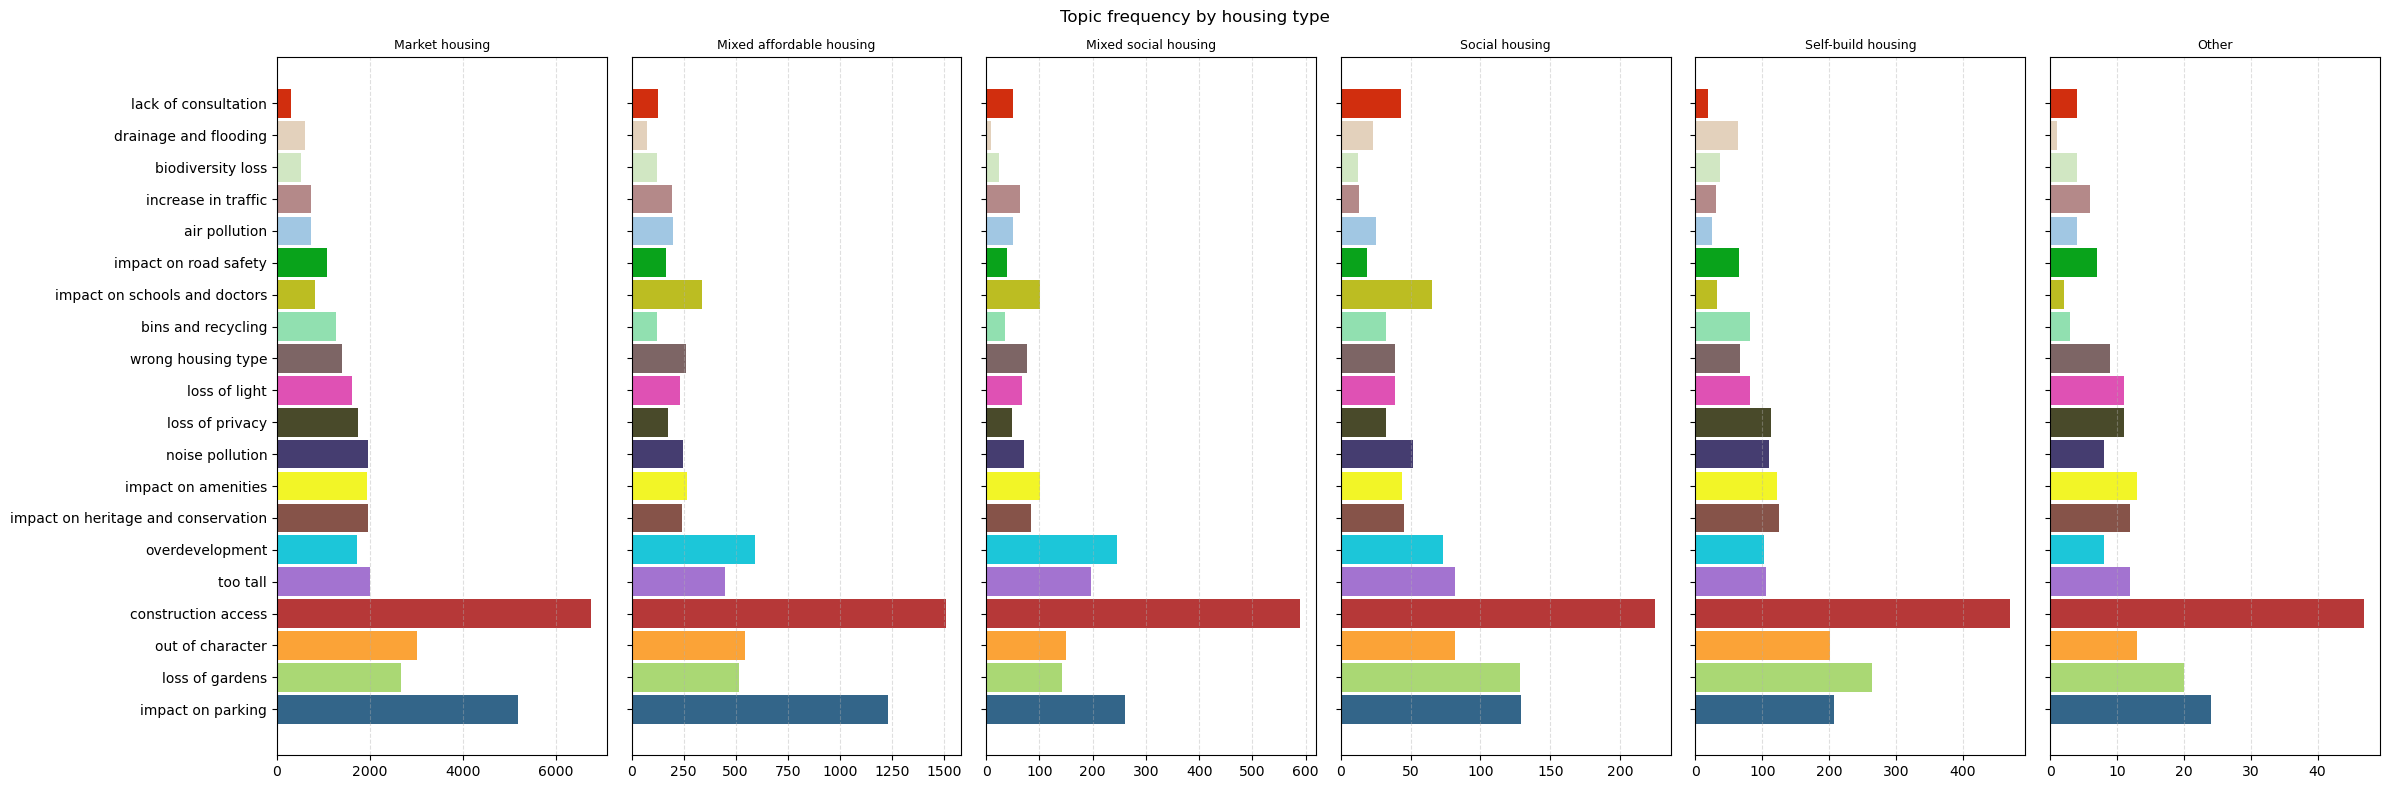

In [9]:
desired_order = [h for h in HOUSING_ORDER if h in df["housing_type"].dropna().unique()]

fig, axes = plt.subplots(1, len(desired_order), figsize=(4 * len(desired_order), 8), sharey=True)

for ax, ht in zip(axes, desired_order):
    ht_counts = (
        df[df["housing_type"] == ht]["topic_number"]
        .explode().value_counts().rename("count")
    )
    sub = (
        topic_names[["Topic", "topic_group", "color"]]
        .merge(ht_counts, left_on="Topic", right_index=True, how="left")
        .fillna({"count": 0})
        .iloc[:n_vals]
    )
    ax.barh(sub["topic_group"], sub["count"], color=sub["color"], height=0.9)
    ax.invert_yaxis()
    ax.set_title(ht, fontsize=9)
    ax.grid(axis='x', linestyle='--', linewidth=0.8, alpha=0.4)
plt.suptitle("Topic frequency by housing type")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "topic_by_housing_type.png", dpi=150, bbox_inches="tight")
plt.show()

## Sentiment by topic

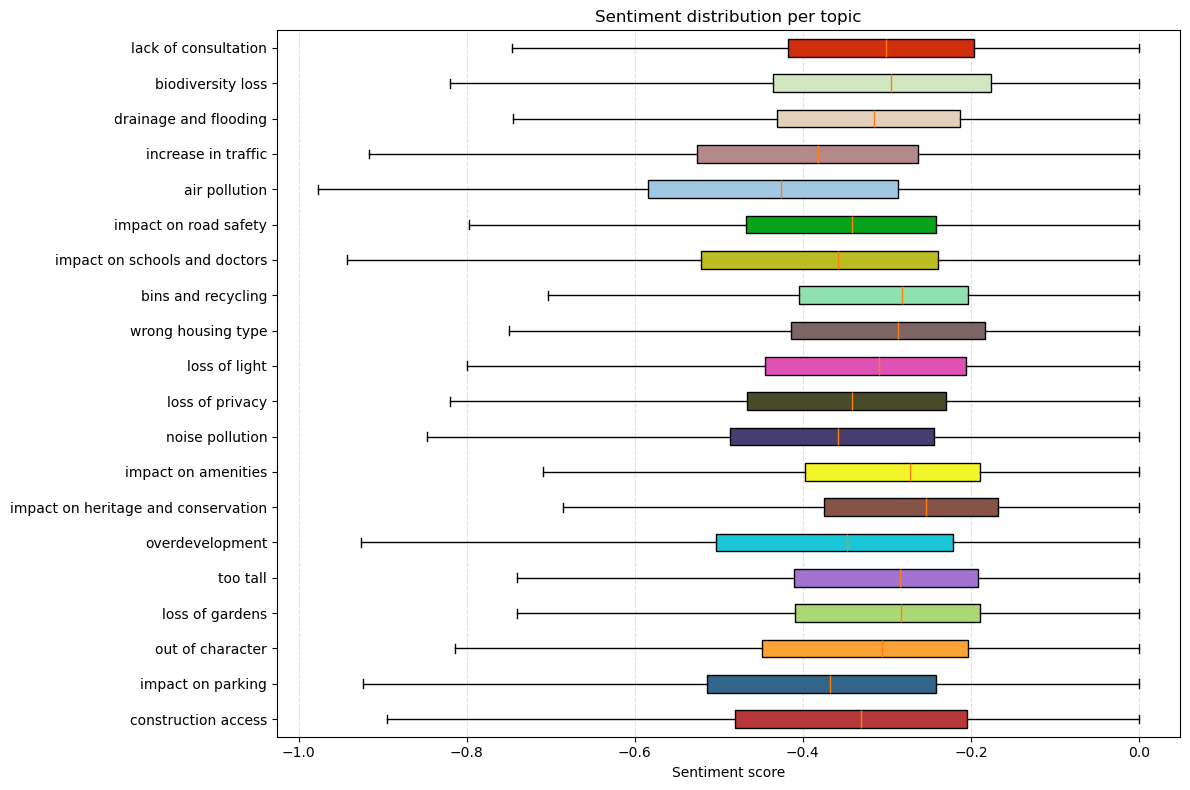

In [14]:
n_vals = 20
fig, ax = plt.subplots(figsize=(12, 8))
data  = [
    df.explode("topic_number").loc[
        lambda d: d["topic_number"] == t, "sentiment_score"
    ].dropna()
    for t in plot_df["Topic"].iloc[:n_vals]
]
box =ax.boxplot(data, vert=False, patch_artist=True, showfliers=False)

# apply topic colours to boxes
for patch, color in zip(box['boxes'], plot_df["color"].iloc[:n_vals]):
    patch.set_facecolor(color)  

ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_yticks(range(1, n_vals + 1))
ax.set_yticklabels(plot_df["topic_group"].iloc[:n_vals])
ax.set_xlabel("Sentiment score")
ax.set_title("Sentiment distribution per topic")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sentiment_by_topic.png", dpi=150, bbox_inches="tight")
plt.show()

## Topic co-occurrence (top 15)

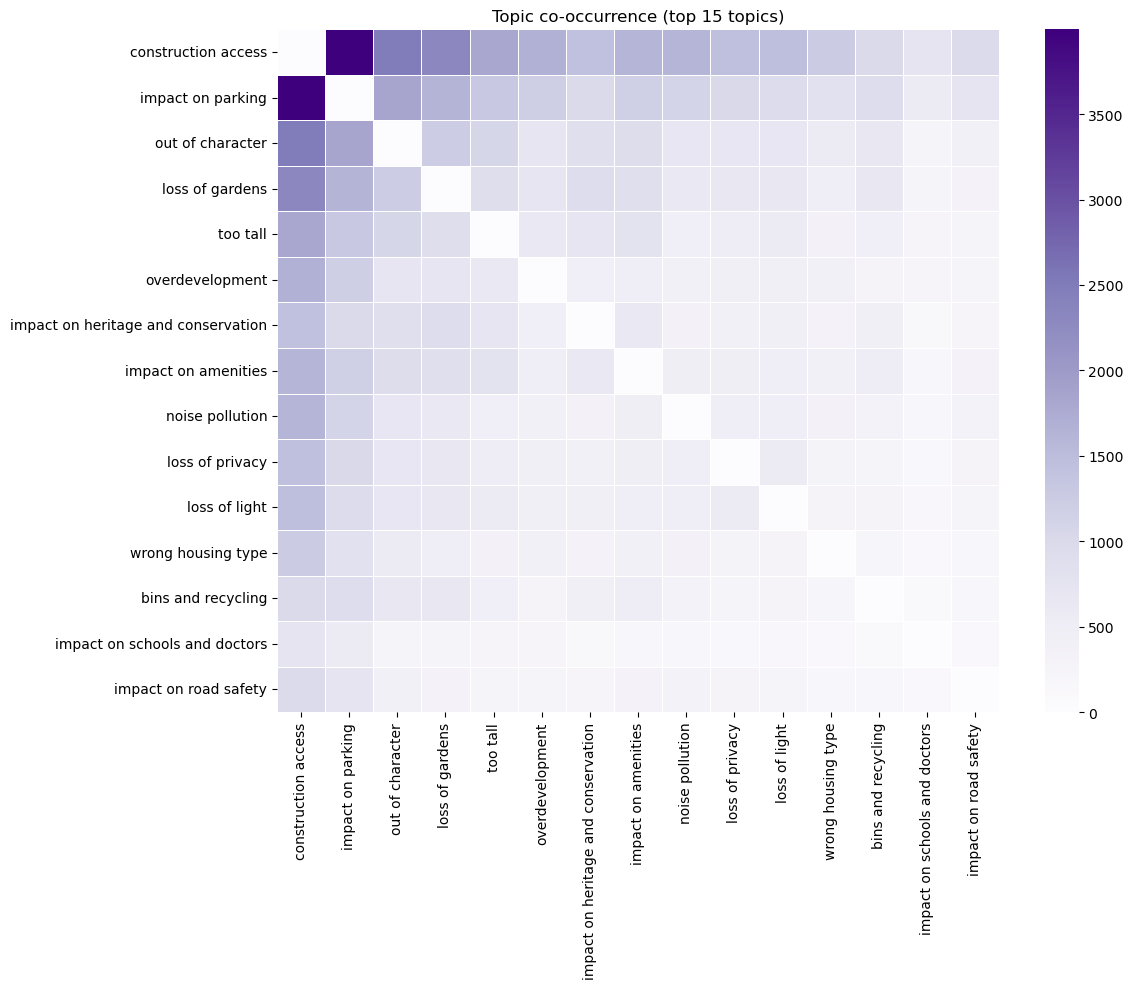

In [8]:
top15 = [t for t, _ in Counter(df["topic_number"].explode().dropna()).most_common(15)]

co = defaultdict(lambda: defaultdict(int))
for topics in df["topic_number"].dropna():
    for t1, t2 in combinations(set(topics) & set(top15), 2):
        co[t1][t2] += 1
        co[t2][t1] += 1

matrix = pd.DataFrame(0, index=top15, columns=top15)
for t1 in top15:
    for t2 in top15:
        matrix.loc[t1, t2] = co[t1][t2]

topic_name_lookup = topic_names.set_index("Topic")["topic_group"].to_dict()
matrix.index   = [topic_name_lookup.get(t, t) for t in matrix.index]
matrix.columns = [topic_name_lookup.get(t, t) for t in matrix.columns]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(matrix, ax=ax, cmap="Purples", linewidths=0.5)
ax.set_title("Topic co-occurrence (top 15 topics)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "topic_cooccurrence.png", dpi=150, bbox_inches="tight")
plt.show()